# 5 - FM SDR Demod

SDR-Capture/Replay nach dem Prinzip aus Labor 3, danach FM-Demodulation analog zu `4-FM-IQ-demod.ipynb`.

Ablauf:
1. IQ-Samples vom RTL-SDR einlesen (oder Replay/Fallback)
2. Trägerlage aus Spektrum schätzen
3. IQ-Rekonstruktion via komplexem LO und FIR-Tiefpass hoher Ordnung (scipy.signal)
4. FM-Demodulation per Phasendifferenz
5. Audio-Feedback

## Parameter und Imports

In [11]:
import os
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.signal import firwin

# SDR / Replay 
USE_REPLAY = False
REPLAY_FILE = Path('recordings/fm_sdr_replay.json')
CENTER_FREQ_HZ = 100e6
SAMPLE_RATE_HZ = 1.024e6
GAIN_DB = 40.0
TOTAL_SAMPLES = 262_144 * 4

# --- HIER DIE DAUER DEFINIEREN ---
AUFNAHME_DAUER_S = 2.0  # <--- Das schreibst du jetzt neu hin!

# Berechne TOTAL_SAMPLES basierend auf der Dauer
TOTAL_SAMPLES = int(SAMPLE_RATE_HZ * AUFNAHME_DAUER_S)

# Damit der SDR-Treiber glücklich ist, runden wir auf ein Vielfaches von 1024
TOTAL_SAMPLES = (TOTAL_SAMPLES // 1024) * 1024

# Diese Zeile berechnet nun automatisch die echten 5 Sekunden
total_sampling_duration = TOTAL_SAMPLES / SAMPLE_RATE_HZ

# Spektrum
N_fft = 16384 * 4
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'


# Demod / Plot
t_plot_ms = 6.0

# Audio
fs_audio = 48_000
start_s = 0.0
duration_s = max(5.0,total_sampling_duration)

print(f'Total Sampling Duration={total_sampling_duration} sec')

Total Sampling Duration=2.0 sec


## 1) Hilfsfunktionen (Capture/Replay/Fallback)

In [12]:
def _window(n: int, use_window: bool = True, kind: str = 'hann') -> np.ndarray:
    if not use_window:
        return np.ones(n)
    if kind == 'hann':
        return np.hanning(n)
    if kind == 'hamming':
        return np.hamming(n)
    return np.ones(n)


def save_replay_iq(path: Path, iq: np.ndarray, fs_hz: float):
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {
        'fs_hz': float(fs_hz),
        'iq_real': np.real(iq).tolist(),
        'iq_imag': np.imag(iq).tolist(),
    }
    path.write_text(json.dumps(data), encoding='utf-8')


def load_replay_iq(path: Path):
    data = json.loads(path.read_text(encoding='utf-8'))
    iq = np.array(data['iq_real'], dtype=np.float32) + 1j*np.array(data['iq_imag'], dtype=np.float32)
    fs_hz = float(data.get('fs_hz', SAMPLE_RATE_HZ))
    return iq.astype(np.complex64), fs_hz


def setup_rtlsdr_driver_path() -> None:
    """Sucht rtl-sdr-driver im Workspace und ergänzt PATH/DLL-Suchpfad."""
    driver_dir = None
    for p in [Path.cwd()] + list(Path.cwd().parents):
        cand = p / 'rtl-sdr-driver'
        if cand.exists() and (cand / 'librtlsdr.dll').exists():
            driver_dir = cand
            break

    if driver_dir is not None:
        os.environ['PATH'] = str(driver_dir) + os.pathsep + os.environ.get('PATH', '')
        try:
            os.add_dll_directory(str(driver_dir))
        except Exception:
            pass
        print('RTL-SDR Treiber gefunden:', driver_dir)
    else:
        print('Hinweis: rtl-sdr-driver nicht gefunden, ggf. Fallback-Signal wird genutzt.')


def capture_rtlsdr(center_hz: float, fs_hz: float, gain_db: float, total_samples: int):
    setup_rtlsdr_driver_path()

    try:
        from rtlsdr import RtlSdr
    except Exception as ex:
        raise RuntimeError(f'rtlsdr nicht verfügbar: {ex}')

    sdr = RtlSdr()
    sdr.sample_rate = fs_hz
    sdr.center_freq = center_hz
    sdr.gain = gain_db
    iq = sdr.read_samples(total_samples).astype(np.complex64)
    iq = sdr.read_samples(total_samples).astype(np.complex64)
    sdr.close()
    return iq


def synthetic_fm_fallback(fs_hz: float, total_samples: int):
    t = np.arange(total_samples) / fs_hz
    f_if = 35_000.0
    f_m = 1_000.0
    delta_f = 3_000.0
    u = np.cos(2*np.pi*f_m*t)
    int_u = np.cumsum(u) / fs_hz
    phase = 2*np.pi*f_if*t + 2*np.pi*delta_f*int_u
    z = np.exp(1j*phase)
    return z.astype(np.complex64)

## 2) Capture oder Replay laden

In [13]:
if USE_REPLAY and REPLAY_FILE.exists():
    iq, fs = load_replay_iq(REPLAY_FILE)
    print('Replay-IQ geladen:', REPLAY_FILE)
else:
    try:
        iq = capture_rtlsdr(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, TOTAL_SAMPLES)
        fs = float(SAMPLE_RATE_HZ)
        save_replay_iq(REPLAY_FILE, iq, fs)
        print('Replay-IQ gespeichert:', REPLAY_FILE)
    except Exception as ex:
        print('RTL-SDR nicht verfügbar, nutze synthetischen Fallback:', ex)
        iq = synthetic_fm_fallback(SAMPLE_RATE_HZ, TOTAL_SAMPLES)
        fs = float(SAMPLE_RATE_HZ)
        save_replay_iq(REPLAY_FILE, iq, fs)
        print('Fallback-IQ gespeichert:', REPLAY_FILE)

if iq.size < TOTAL_SAMPLES:
    raise RuntimeError(f'Zu wenige Samples: {iq.size} < {TOTAL_SAMPLES}')
iq = iq[:TOTAL_SAMPLES].astype(np.complex64)

N = len(iq)
t = np.arange(N) / fs
n_plot = min(N, int(t_plot_ms * 1e-3 * fs))
print(f'Samples: {N}, fs={fs:.1f} Hz')

RTL-SDR Treiber gefunden: C:\Users\holzi\Desktop\FH\4_Semester\KT\Git\KT-course\rtl-sdr-driver
Replay-IQ gespeichert: recordings\fm_sdr_replay.json
Samples: 2048000, fs=1024000.0 Hz


## 3) Spektrum des eingelesenen komplexen IQ-Signals und Träger-/LO-Schätzung

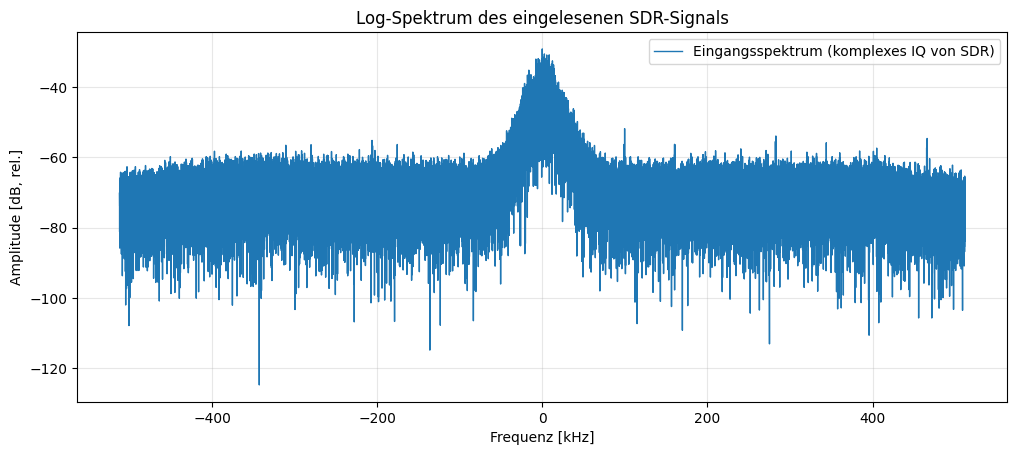

In [14]:
x_pad = np.zeros(N_fft, dtype=np.complex128)    # falls Signallänge < FFT-Länge, padding mit Null
x_pad[:min(N, N_fft)] = iq[:min(N, N_fft)]
w = _window(N_fft, USE_FFT_WINDOW, FFT_WINDOW_KIND)
cg = np.mean(w)                                 # gain compensation der window-function
S = np.fft.fftshift(np.fft.fft(x_pad * w, n=N_fft))
f_spec = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
A = np.abs(S) / max(N_fft * cg, 1e-12)
S_db = 20*np.log10(np.maximum(A, 1e-12))   # log-Spektrum

plt.figure(figsize=(12, 4.8))
plt.plot(f_spec/1e3, S_db, lw=1.0, label='Eingangsspektrum (komplexes IQ von SDR)')
plt.title('Log-Spektrum des eingelesenen SDR-Signals')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB, rel.]')
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## Schätzung der Trägerfrequenz

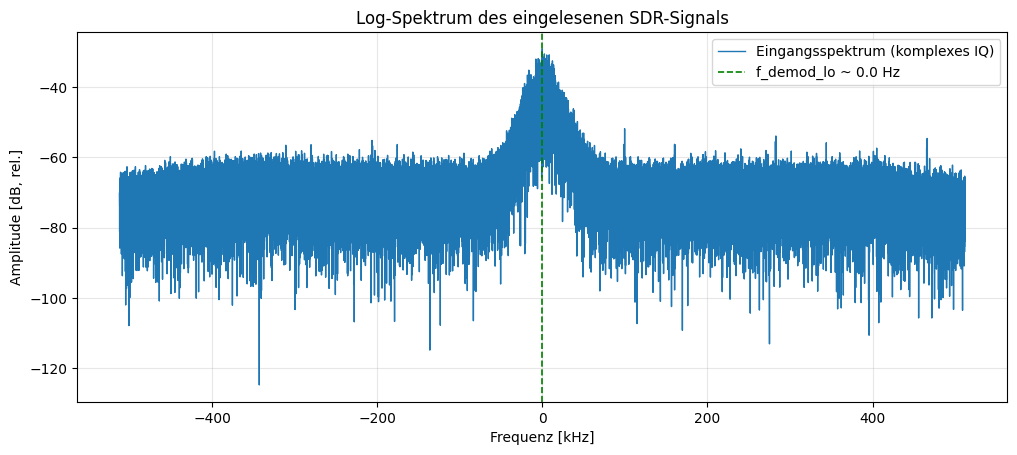

Geschätzte Demod-LO-Frequenz: 0.0 Hz


In [15]:

# Trage HIER eine Schätzung der Trägerfrequenz ein
f_demod_lo = 0.0

plt.figure(figsize=(12, 4.8))
plt.plot(f_spec/1e3, S_db, lw=1.0, label='Eingangsspektrum (komplexes IQ)')
plt.axvline(f_demod_lo/1e3, color='g', ls='--', lw=1.2, label=f'f_demod_lo ~ {f_demod_lo:.1f} Hz')
plt.title('Log-Spektrum des eingelesenen SDR-Signals')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB, rel.]')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'Geschätzte Demod-LO-Frequenz: {f_demod_lo:.1f} Hz')

## 4) TODO: Komplexes Heruntermischen (Downconversion)

$$u[n] = iq[n]\cdot e^{-j2\pi f_{demod}n/f_s}$$


In [16]:
t = np.arange(len(iq)) / fs
lo_cx = np.exp(-1j * (2 * np.pi * f_demod_lo * t))
u_mix = iq * lo_cx

I_raw = np.real(u_mix)
Q_raw = np.imag(u_mix)

print(f'Downconversion fertig: f_demod_lo={f_demod_lo:.1f} Hz, Samples={len(u_mix)}')


Downconversion fertig: f_demod_lo=0.0 Hz, Samples=2048000


## 4a) Spektrum des heruntergemischten Signals (vor FIR)


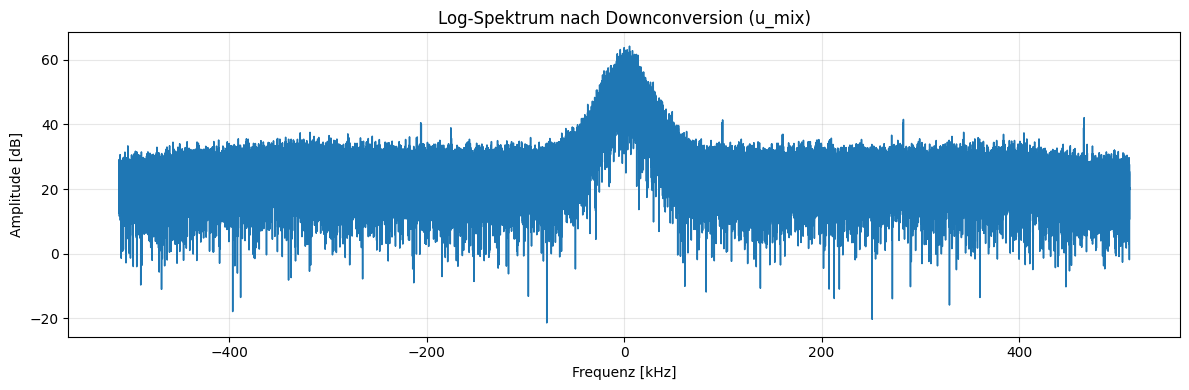

In [17]:
x_mix = np.zeros(N_fft, dtype=np.complex128)
x_mix[:min(len(u_mix), N_fft)] = u_mix[:min(len(u_mix), N_fft)]
X_mix = np.fft.fftshift(np.fft.fft(x_mix))
f_axis_mix = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/fs))
A_mix_db = 20*np.log10(np.maximum(np.abs(X_mix), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(f_axis_mix/1e3, A_mix_db, lw=1.1)
plt.title('Log-Spektrum nach Downconversion (u_mix)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4b) FIR-Tiefpass und Spektrum des gefilterten Signals

$$z_{bb}[n]=(u*h_{FIR})[n]$$

Konfigurierbar über Tap-Anzahl, Grenzfrequenz, Fensterfunktion und Faltungsmodus.


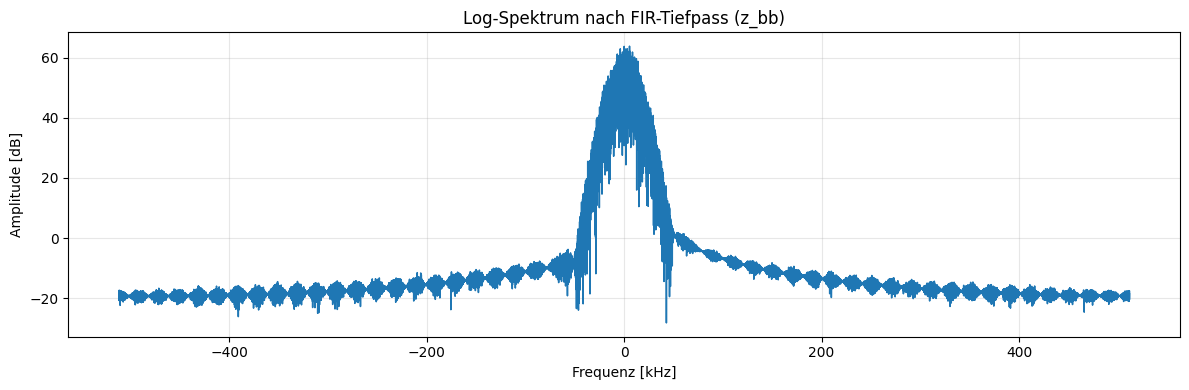

FIR-Tiefpass: taps=51, cutoff=15000.0 Hz, window=hamming, mode=same


In [18]:
# FIR-Parameter (konfigurierbar)
FIR_NUM_TAPS = 51                # Tap-Länge (ungerade empfohlen)
FIR_CUTOFF_HZ = 15_000.0           # Grenzfrequenz [Hz]
FIR_WINDOW = 'hamming'            # z.B. 'hann', 'hamming', 'blackman'
FIR_APPLY_MODE = 'same'           # 'full' | 'same' | 'valid'

nyq = 0.5 * fs
cutoff_norm = min(max(FIR_CUTOFF_HZ / nyq, 1e-6), 0.999)
num_taps = int(FIR_NUM_TAPS)
if num_taps % 2 == 0:
    num_taps += 1

h_fir = firwin(num_taps, cutoff=cutoff_norm, window=FIR_WINDOW, pass_zero='lowpass')
I_bb = np.convolve(I_raw, h_fir, mode=FIR_APPLY_MODE)
Q_bb = np.convolve(Q_raw, h_fir, mode=FIR_APPLY_MODE)
z_bb = I_bb + 1j * Q_bb

x_f = np.zeros(N_fft, dtype=np.complex128)
x_f[:min(len(z_bb), N_fft)] = z_bb[:min(len(z_bb), N_fft)]
X_f = np.fft.fftshift(np.fft.fft(x_f))
f_axis_f = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/fs))
A_f_db = 20*np.log10(np.maximum(np.abs(X_f), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(f_axis_f/1e3, A_f_db, lw=1.1)
plt.title('Log-Spektrum nach FIR-Tiefpass (z_bb)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f'FIR-Tiefpass: taps={num_taps}, cutoff={FIR_CUTOFF_HZ:.1f} Hz, ' +
    f'window={FIR_WINDOW}, mode={FIR_APPLY_MODE}'
)


## 4b1) FIR-Frequenzgang $|H(f)|$

Darstellung des Amplitudengangs des entworfenen FIR-Tiefpasses in dB.


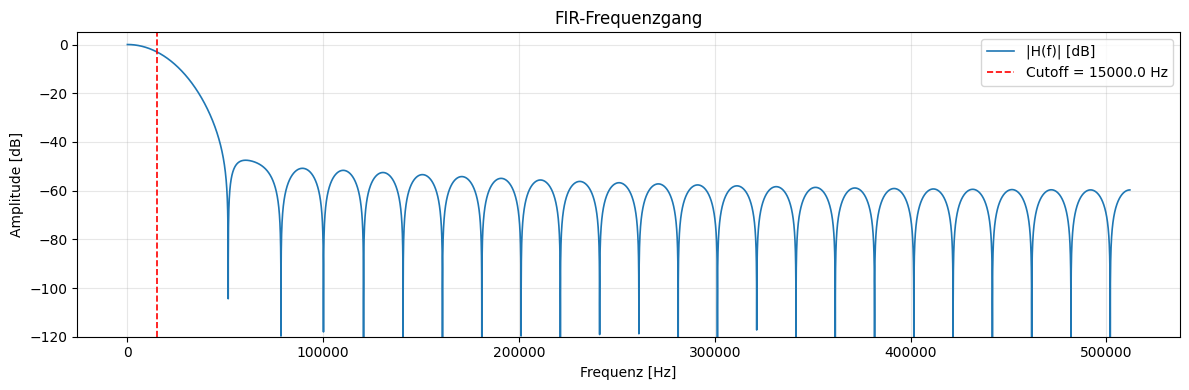

In [19]:
# Frequenzgang des FIR-Filters (ohne Zusatzfunktionen)
N_resp = max(4096, N_fft)
H = np.fft.rfft(h_fir, n=N_resp)
f_resp = np.fft.rfftfreq(N_resp, d=1/fs)
H_db = 20*np.log10(np.maximum(np.abs(H), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(f_resp, H_db, lw=1.2, label='|H(f)| [dB]')
plt.axvline(FIR_CUTOFF_HZ, color='r', ls='--', lw=1.2, label=f'Cutoff = {FIR_CUTOFF_HZ:.1f} Hz')
plt.title('FIR-Frequenzgang')
plt.xlabel('Frequenz [Hz]')
plt.ylabel('Amplitude [dB]')
plt.ylim(-120, 5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 4c) Zeitbereichsplots für I- und Q-Signal (nach FIR)


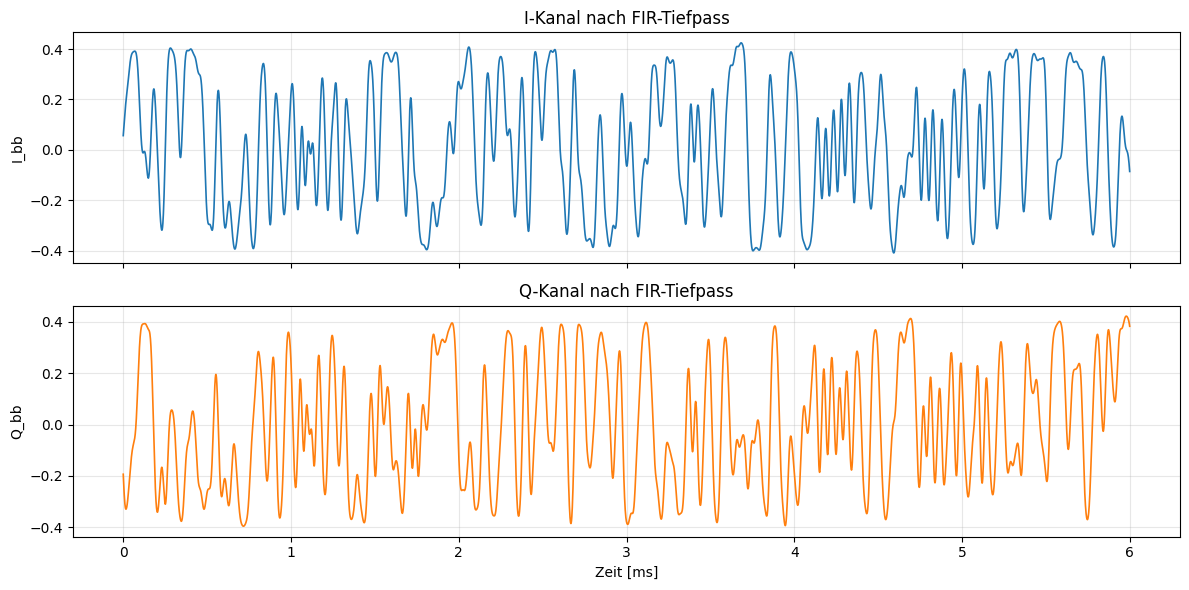

In [20]:
plot_ms = float(globals().get('TIME_PLOT_MS', globals().get('t_plot_ms', 6.0)))
n_plot = min(len(I_bb), int(plot_ms * 1e-3 * fs))
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, I_bb[:n_plot], lw=1.2)
ax[0].set_title('I-Kanal nach FIR-Tiefpass')
ax[0].set_ylabel('I_bb')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, Q_bb[:n_plot], lw=1.2, color="tab:orange")
ax[1].set_title('Q-Kanal nach FIR-Tiefpass')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Q_bb')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5) TODO: FM-Demodulation

$$d[n]=z_{bb}[n]\,z_{bb}^*[n-1],\; FM_{disc}[n]=\angle\{d[n]\}$$

In [21]:
# Ersetze die Platzhalter gemäß den angegebenen Formeln
d = z_bb[1:] * np.conjugate(z_bb[:-1])
fm_disc = np.angle(d)

# einfache Nachfilterung auf dem Demodsignal
N_win_demod = max(5, int(np.round(0.002 * fs)))
if N_win_demod % 2 == 0:
    N_win_demod += 1
h_demod = np.ones(N_win_demod) / N_win_demod
u_demod = np.convolve(fm_disc, h_demod, mode='same')

print(f'Demod-Nachfilter: N_win_demod = {N_win_demod}')

Demod-Nachfilter: N_win_demod = 2049


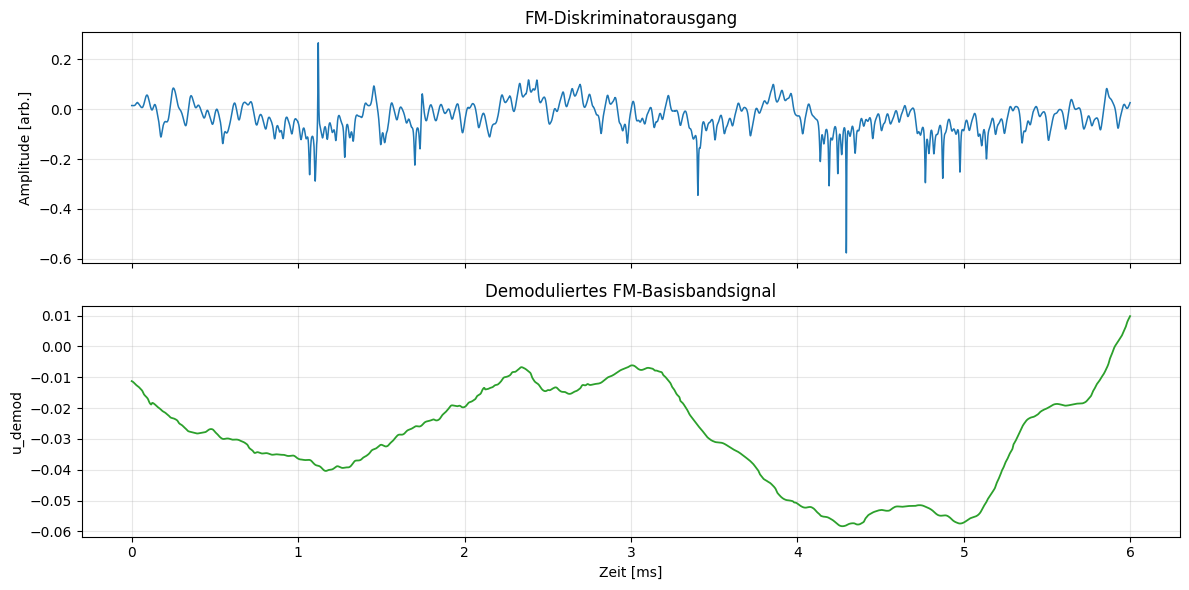

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, fm_disc[:n_plot], lw=1.1)
ax[0].set_title('FM-Diskriminatorausgang')
ax[0].set_ylabel('Amplitude [arb.]')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, u_demod[:n_plot], lw=1.3, color='tab:green')
ax[1].set_title('Demoduliertes FM-Basisbandsignal')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('u_demod')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6) Audiofeedback

In [23]:
# Audio-Resampling auf 48kHz Abtastrate
if fs != fs_audio:
    t_src = np.arange(len(u_demod)) / fs
    n_dst = int(len(u_demod) * fs_audio / fs)
    t_dst = np.arange(n_dst) / fs_audio
    x_audio_full = np.interp(t_dst, t_src, u_demod)
else:
    x_audio_full = u_demod.copy()

max_start_s = max(0.0, (len(x_audio_full) - 1) / fs_audio)
start_s_eff = min(max(float(start_s), 0.0), max_start_s)
if start_s_eff != float(start_s):
    print(f'Hinweis: start_s={start_s:.2f} s liegt außerhalb. Verwende start_s={start_s_eff:.2f} s.')

start_idx = int(start_s_eff * fs_audio)
x_audio_seg = x_audio_full[start_idx:]
target_len = int(duration_s * fs_audio)
rep = max(1, int(np.ceil(target_len / len(x_audio_seg))))
x_audio = np.tile(x_audio_seg, rep)[:target_len]
x_audio = x_audio / max(np.max(np.abs(x_audio)), 1e-12)

print(f'Audio vorbereitet: Start={start_s_eff:.2f} s, {len(x_audio)} Samples @ {fs_audio} Hz, Dauer {len(x_audio)/fs_audio:.2f} s')
display(Audio(x_audio, rate=fs_audio))

Audio vorbereitet: Start=0.00 s, 240000 Samples @ 48000 Hz, Dauer 5.00 s
